# 2025 COMP90042 Project
*Make sure you change the file name with your group id.*

In [ ]:
import datasets

In [ ]:
!pip install --upgrade datasets

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1.DataSet Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
!ls /content/drive/MyDrive/Colab\ Notebooks/comp90042_a3/data

dev-claims-baseline.json  evidence.json		       train-claims.json
dev-claims.json		  evidence.md
eval.py			  test-claims-unlabelled.json


In [ ]:
import json

# load training data
TRAINING_FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/comp90042_a3/data/train-claims.json'
with open(TRAINING_FILE_PATH, 'r') as f:
    train_data = json.load(f)

# load development data
DEV_FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/comp90042_a3/data/dev-claims.json'
with open(DEV_FILE_PATH, 'r') as f:
    dev_data = json.load(f)

# load evidence
EVIDENCE_FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/comp90042_a3/data/evidence.json'
with open(EVIDENCE_FILE_PATH, 'r') as f:
    evidence = json.load(f)

In [ ]:
from itertools import islice

# print the first 5 training claims and supporting evidence
train_sample = dict(islice(train_data.items(), 5))
train_sample

{'claim-1937': {'claim_text': 'Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.',
  'claim_label': 'DISPUTED',
  'evidences': ['evidence-442946', 'evidence-1194317', 'evidence-12171']},
 'claim-126': {'claim_text': 'El Niño drove record highs in global temperatures suggesting rise may not be down to man-made emissions.',
  'claim_label': 'REFUTES',
  'evidences': ['evidence-338219', 'evidence-1127398']},
 'claim-2510': {'claim_text': 'In 1946, PDO switched to a cool phase.',
  'claim_label': 'SUPPORTS',
  'evidences': ['evidence-530063', 'evidence-984887']},
 'claim-2021': {'claim_text': 'Weather Channel co-founder John Coleman provided evidence that convincingly refutes the concept of anthropogenic global warming.',
  'claim_label': 'DISPUTED',
  'evidences': ['evidence-1177431',
   'evidence-782448',
   'evidence-540069',
   'evidence-352655',
   'evidence-1007867']},
 'claim-2449'

In [ ]:
# print the first 5 dev claims
dev_sample = dict(islice(dev_data.items(), 5))
dev_sample

{'claim-752': {'claim_text': '[South Australia] has the most expensive electricity in the world.',
  'claim_label': 'SUPPORTS',
  'evidences': ['evidence-67732', 'evidence-572512']},
 'claim-375': {'claim_text': 'when 3 per cent of total annual global emissions of carbon dioxide are from humans and Australia prod\xaduces 1.3 per cent of this 3 per cent, then no amount of emissions reductio\xadn here will have any effect on global climate.',
  'claim_label': 'NOT_ENOUGH_INFO',
  'evidences': ['evidence-996421',
   'evidence-1080858',
   'evidence-208053',
   'evidence-699212',
   'evidence-832334']},
 'claim-1266': {'claim_text': 'This means that the world is now 1C warmer than it was in pre-industrial times',
  'claim_label': 'SUPPORTS',
  'evidences': ['evidence-889933', 'evidence-694262']},
 'claim-871': {'claim_text': '“As it happens, Zika may also be a good model of the second worrying effect — disease mutation.',
  'claim_label': 'NOT_ENOUGH_INFO',
  'evidences': ['evidence-422399

In [ ]:
# print a sample of the 5 evidences
evidence_sample = dict(islice(evidence.items(), 5))
evidence_sample

{'evidence-0': 'John Bennet Lawes, English entrepreneur and agricultural scientist',
 'evidence-1': 'Lindberg began his professional career at the age of 16, eventually moving to New York City in 1977.',
 'evidence-2': "``Boston (Ladies of Cambridge)'' by Vampire Weekend",
 'evidence-3': 'Gerald Francis Goyer (born October 20, 1936) was a professional ice hockey player who played 40 games in the National Hockey League.',
 'evidence-4': 'He detected abnormalities of oxytocinergic function in schizoaffective mania, post-partum psychosis and how ECT modified oxytocin release.'}

In [ ]:
import json
import pandas as pd
from pathlib import Path

# Label map
label_map = {"SUPPORTS": 0, "REFUTES": 1, "NOT_ENOUGH_INFO": 2, "DISPUTED": 3}

# Combine claim with available evidence
train_rows = []
for claim_id, claim_info in train_data.items():
    label = label_map.get(claim_info["claim_label"], -1)
    for evidence_id in claim_info["evidences"]:
        if evidence_id in evidence:
            train_rows.append({
                "claim_id": claim_id,
                "evidence_id": evidence_id,
                "claim": claim_info["claim_text"],
                "evidence": evidence[evidence_id],
                "label": label
            })

# Process dev set
dev_rows = []
for claim_id, claim_info in dev_data.items():
    label = label_map.get(claim_info["claim_label"], -1)
    for evidence_id in claim_info["evidences"]:
        if evidence_id in evidence:
            dev_rows.append({
                "claim_id": claim_id,
                "evidence_id": evidence_id,
                "claim": claim_info["claim_text"],
                "evidence": evidence[evidence_id],
                "label": label
            })

# create dataframes
train_df = pd.DataFrame(train_rows)
dev_df = pd.DataFrame(dev_rows)

train_df


,claim_id,evidence_id,claim,evidence,label
0,claim-1937,evidence-442946,Not only is there no scientific evidence that ...,At very high concentrations (100 times atmosph...,3
1,claim-1937,evidence-1194317,Not only is there no scientific evidence that ...,Plants can grow as much as 50 percent faster i...,3
2,claim-1937,evidence-12171,Not only is there no scientific evidence that ...,Higher carbon dioxide concentrations will favo...,3
3,claim-126,evidence-338219,El Niño drove record highs in global temperatu...,While ‘climate change’ can be due to natural f...,1
4,claim-126,evidence-1127398,El Niño drove record highs in global temperatu...,This acceleration is due mostly to human-cause...,1
...,...,...,...,...,...
4117,claim-502,evidence-583187,But abnormal temperature spikes in February an...,The coastline sees significantly mild temperat...,2
4118,claim-3093,evidence-971105,Sending oscillating microwaves from an antenna...,"Dielectric heating, also known as electronic h...",0
4119,claim-3093,evidence-457769,Sending oscillating microwaves from an antenna...,An example is absorption or emission of radio ...,0
4120,claim-3093,evidence-298971,Sending oscillating microwaves from an antenna...,"Water, fat, and other substances in the food a...",0


In [ ]:
dev_df

,claim_id,evidence_id,claim,evidence,label
0,claim-752,evidence-67732,[South Australia] has the most expensive elect...,[citation needed] South Australia has the high...,0
1,claim-752,evidence-572512,[South Australia] has the most expensive elect...,"""South Australia has the highest power prices ...",0
2,claim-375,evidence-996421,when 3 per cent of total annual global emissio...,The 2011 UNEP Green Economy report states that...,2
3,claim-375,evidence-1080858,when 3 per cent of total annual global emissio...,With a market share of 30% and (potentially) c...,2
4,claim-375,evidence-208053,when 3 per cent of total annual global emissio...,"In the modern era, emissions to the atmosphere...",2
...,...,...,...,...,...
486,claim-1426,evidence-288294,Many of the world’s coral reefs are already ba...,Aquaculture is showing promise as a potentiall...,2
487,claim-1426,evidence-946262,Many of the world’s coral reefs are already ba...,This can rapidly result in transitions to barr...,2
488,claim-698,evidence-660755,A recent study led by Lawrence Livermore Natio...,"A 2007 study by David Douglass and coworkers, ...",1
489,claim-1021,evidence-242575,"The corals may save themselves, as many other ...",The poleward migration of coral species refers...,0


In [ ]:
claim_row = dev_df[dev_df['claim_id'] == 'claim-1937']
print(claim_row)

Empty DataFrame
Columns: [claim_id, evidence_id, claim, evidence, label]
Index: []


//talk about explainable IR or heuristics... compare preprocessed inputs vs raw as an ablation study


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))


# convert part of speech tagging
def convert_wordnet_tag(old_tag):
    match old_tag[0].upper():
        case 'R':
            return wordnet.ADV
        case 'J':
            return wordnet.ADJ
        case 'N':
            return wordnet.NOUN
        case 'V':
            return wordnet.VERB
        case _:
            return wordnet.NOUN
def preprocess(text: str):
    lemmatiser = WordNetLemmatizer()
    # Tokenize
    tokens = word_tokenize(text.lower())
    # create part of speech tags
    POS_tags = nltk.pos_tag(tokens)

    english_tokens = []

    # convert tag to be usable with wordnet and convert token to lemma
    for token, tag in POS_tags:
        wordnet_tag = convert_wordnet_tag(tag)
        if wordnet_tag is None:
            continue
        if any(c.isalpha() for c in token):
            lemma = lemmatiser.lemmatize(token, wordnet_tag)
            if lemma not in stop_words:
              english_tokens.append(lemma)

    return english_tokens

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
tokenized_df = train_df.copy()
tokenized_df['claim'] = tokenized_df['claim'].apply(preprocess)
tokenized_df['evidence'] = tokenized_df['evidence'].apply(preprocess)
tokenized_df

,claim_id,evidence_id,claim,evidence,label
0,claim-1937,evidence-442946,"[scientific, evidence, co2, pollutant, high, c...","[high, concentration, time, atmospheric, conce...",3
1,claim-1937,evidence-1194317,"[scientific, evidence, co2, pollutant, high, c...","[plant, grow, much, percent, faster, concentra...",3
2,claim-1937,evidence-12171,"[scientific, evidence, co2, pollutant, high, c...","[high, carbon, dioxide, concentration, favoura...",3
3,claim-126,evidence-338219,"[el, niño, drove, record, highs, global, tempe...","[climate, change, due, natural, force, human, ...",1
4,claim-126,evidence-1127398,"[el, niño, drove, record, highs, global, tempe...","[acceleration, due, mostly, human-caused, glob...",1
...,...,...,...,...,...
4117,claim-502,evidence-583187,"[abnormal, temperature, spike, february, earli...","[coastline, see, significantly, mild, temperat...",2
4118,claim-3093,evidence-971105,"[send, oscillate, microwave, antenna, inside, ...","[dielectric, heating, also, know, electronic, ...",0
4119,claim-3093,evidence-457769,"[send, oscillate, microwave, antenna, inside, ...","[example, absorption, emission, radio, wave, a...",0
4120,claim-3093,evidence-298971,"[send, oscillate, microwave, antenna, inside, ...","[water, fat, substance, food, absorb, energy, ...",0


### Unprocessed Claims and Evidences for Semantic methods

In [ ]:
claim_df = train_df[['claim_id', 'claim']].drop_duplicates('claim_id')
claim_df

,claim_id,claim
0,claim-1937,Not only is there no scientific evidence that ...
3,claim-126,El Niño drove record highs in global temperatu...
5,claim-2510,"In 1946, PDO switched to a cool phase."
7,claim-2021,Weather Channel co-founder John Coleman provid...
12,claim-2449,"""January 2008 capped a 12 month period of glob..."
...,...,...
4103,claim-1504,Climate scientists say that aspects of the cas...
4107,claim-243,"In its 5th assessment report in 2013, the IPCC..."
4108,claim-2302,"Since the mid 1970s, global temperatures have ..."
4113,claim-502,But abnormal temperature spikes in February an...


In [ ]:
evidence_df = train_df[['evidence_id', 'evidence']].drop_duplicates('evidence_id')
evidence_df

,evidence_id,evidence
0,evidence-442946,At very high concentrations (100 times atmosph...
1,evidence-1194317,Plants can grow as much as 50 percent faster i...
2,evidence-12171,Higher carbon dioxide concentrations will favo...
3,evidence-338219,While ‘climate change’ can be due to natural f...
4,evidence-1127398,This acceleration is due mostly to human-cause...
...,...,...
4117,evidence-583187,The coastline sees significantly mild temperat...
4118,evidence-971105,"Dielectric heating, also known as electronic h..."
4119,evidence-457769,An example is absorption or emission of radio ...
4120,evidence-298971,"Water, fat, and other substances in the food a..."


### Tokenized Unique Claims and Evidences for Lexical method

In [ ]:
tokenized_claim_df = tokenized_df[['claim_id', 'claim']].drop_duplicates('claim_id')
tokenized_claim_df

,claim_id,claim
0,claim-1937,"[scientific, evidence, co2, pollutant, high, c..."
3,claim-126,"[el, niño, drove, record, highs, global, tempe..."
5,claim-2510,"[pdo, switch, cool, phase]"
7,claim-2021,"[weather, channel, co-founder, john, coleman, ..."
12,claim-2449,"[january, cap, month, period, global, temperat..."
...,...,...
4103,claim-1504,"[climate, scientist, say, aspect, case, hurric..."
4107,claim-243,"[5th, assessment, report, ipcc, estimate, huma..."
4108,claim-2302,"[since, mid, 1970s, global, temperature, warm,..."
4113,claim-502,"[abnormal, temperature, spike, february, earli..."


In [ ]:
pretokenized_dev_df = dev_df.copy()
pretokenized_dev_df['claim'] = pretokenized_dev_df['claim'].apply(preprocess)
pretokenized_dev_df['evidence'] = pretokenized_dev_df['evidence'].apply(preprocess)
pretokenized_dev_df

,claim_id,evidence_id,claim,evidence,label
0,claim-752,evidence-67732,"[south, australia, expensive, electricity, world]","[citation, need, south, australia, high, retai...",0
1,claim-752,evidence-572512,"[south, australia, expensive, electricity, world]","[south, australia, high, power, price, world]",0
2,claim-375,evidence-996421,"[per, cent, total, annual, global, emission, c...","[unep, green, economy, report, state, agricult...",2
3,claim-375,evidence-1080858,"[per, cent, total, annual, global, emission, c...","[market, share, potentially, clean, electricit...",2
4,claim-375,evidence-208053,"[per, cent, total, annual, global, emission, c...","[modern, era, emission, atmosphere, volcano, a...",2
...,...,...,...,...,...
486,claim-1426,evidence-288294,"[many, world, coral, reef, already, barren, st...","[aquaculture, show, promise, potentially, effe...",2
487,claim-1426,evidence-946262,"[many, world, coral, reef, already, barren, st...","[rapidly, result, transition, barren, landscap...",2
488,claim-698,evidence-660755,"[recent, study, lead, lawrence, livermore, nat...","[study, david, douglas, coworkers, conclude, c...",1
489,claim-1021,evidence-242575,"[coral, may, save, many, creature, attempt, mo...","[poleward, migration, coral, specie, refers, p...",0


In [ ]:
tokenized_dev_df = pretokenized_dev_df[['claim_id', 'claim']].drop_duplicates('claim_id')
tokenized_dev_df

,claim_id,claim
0,claim-752,"[south, australia, expensive, electricity, world]"
2,claim-375,"[per, cent, total, annual, global, emission, c..."
7,claim-1266,"[mean, world, 1c, warm, pre-industrial, time]"
9,claim-871,"[happen, zika, may, also, good, model, second,..."
14,claim-2164,"[greenland, lose, tiny, fraction, ice, mass]"
...,...,...
474,claim-2400,"['to, suddenly, label, co2, pollutant, disserv..."
478,claim-204,"[natural, orbitally, driven, warming, atmosphe..."
483,claim-1426,"[many, world, coral, reef, already, barren, st..."
488,claim-698,"[recent, study, lead, lawrence, livermore, nat..."


In [ ]:
# Group unique tokenized evidences
tokenized_evidence_df = tokenized_df[['evidence_id', 'evidence']].drop_duplicates(subset='evidence_id')
tokenized_evidence_df

,evidence_id,evidence
0,evidence-442946,"[high, concentration, time, atmospheric, conce..."
1,evidence-1194317,"[plant, grow, much, percent, faster, concentra..."
2,evidence-12171,"[high, carbon, dioxide, concentration, favoura..."
3,evidence-338219,"[climate, change, due, natural, force, human, ..."
4,evidence-1127398,"[acceleration, due, mostly, human-caused, glob..."
...,...,...
4117,evidence-583187,"[coastline, see, significantly, mild, temperat..."
4118,evidence-971105,"[dielectric, heating, also, know, electronic, ..."
4119,evidence-457769,"[example, absorption, emission, radio, wave, a..."
4120,evidence-298971,"[water, fat, substance, food, absorb, energy, ..."


In [ ]:
train_evidence_dict = train_df.set_index('evidence_id')['evidence'].to_dict()
print(train_evidence_dict)

{'evidence-442946': 'At very high concentrations (100 times atmospheric concentration, or greater), carbon dioxide can be toxic to animal life, so raising the concentration to 10,000 ppm (1%) or higher for several hours will eliminate pests such as whiteflies and spider mites in a greenhouse.', 'evidence-1194317': 'Plants can grow as much as 50 percent faster in concentrations of 1,000 ppm CO 2 when compared with ambient conditions, though this assumes no change in climate and no limitation on other nutrients.', 'evidence-12171': 'Higher carbon dioxide concentrations will favourably affect plant growth and demand for water.', 'evidence-338219': 'While ‘climate change’ can be due to natural forces or human activity, there is now substantial evidence to indicate that human activity – and specifically increased greenhouse gas (GHGs) emissions – is a key factor in the pace and extent of global temperature increases.', 'evidence-1127398': 'This acceleration is due mostly to human-caused glo

In [ ]:
true_evidence_dict = (
    tokenized_df
    .groupby('claim_id')['evidence_id']
    .apply(list)
    .to_dict()
)

# 2. Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

CLAIM -> [Retrieval] -> Evidence Candidates -> [Classifier] -> Label

---




# Evidence Retrieval

## BASELINE - BM25

We use BM25 as a lightweight lexical retriever for evidence passages, which efficiently ranks the top-k candidate evidences for a given claim. While it lacks deep semantic understanding, it provides a strong, interpretable, and fast baseline. Importantly, BM25 is fully explainable, fast to test, and requires no training or fine-tuning.

In [ ]:
!pip install rank_bm25

In [ ]:
from rank_bm25 import BM25Okapi

# Build BM25 over evidence
bm25 = BM25Okapi(tokenized_evidence_df['evidence'].tolist())
evidence_ids = tokenized_evidence_df['evidence_id'].tolist()

In [ ]:
# for every claim get their top k evidences
def get_top_k_evidence(claim_tokens, k):
    predicted_dict = {}

    for _, row in claim_tokens.iterrows():
        claim_id = row['claim_id']
        claim_tokens = row['claim']
        scores = bm25.get_scores(claim_tokens)

        top_k = k
        top_k_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
        top_k_evidence_ids = [evidence_ids[i] for i in top_k_indices]

        predicted_dict[claim_id] = top_k_evidence_ids
    return predicted_dict
bm25_pred_dict = get_top_k_evidence(tokenized_claim_df, 30)
print(bm25_pred_dict)

{'claim-1937': ['evidence-66273', 'evidence-1167485', 'evidence-442946', 'evidence-835824', 'evidence-403020', 'evidence-1005062', 'evidence-220309', 'evidence-51588', 'evidence-364767', 'evidence-511878', 'evidence-714864', 'evidence-457314', 'evidence-386428', 'evidence-290948', 'evidence-618811', 'evidence-831116', 'evidence-1036164', 'evidence-12171', 'evidence-98914', 'evidence-985452', 'evidence-499734', 'evidence-469213', 'evidence-247680', 'evidence-1123177', 'evidence-774652', 'evidence-738539', 'evidence-910599', 'evidence-530201', 'evidence-331238', 'evidence-456384'], 'claim-126': ['evidence-606276', 'evidence-553476', 'evidence-1081418', 'evidence-616446', 'evidence-975177', 'evidence-646402', 'evidence-1066389', 'evidence-508793', 'evidence-1115778', 'evidence-398548', 'evidence-118589', 'evidence-605626', 'evidence-757821', 'evidence-875615', 'evidence-430393', 'evidence-81396', 'evidence-882910', 'evidence-215396', 'evidence-611438', 'evidence-97375', 'evidence-494148',

In [ ]:
def compute_retrieval_accuracy(true_evidence_dict, predicted_evidence_dict):

    hit_count = 0
    total = 0

    for claim_id, true_evids in true_evidence_dict.items():
        true_set = set(true_evids)
        pred_set = set(predicted_evidence_dict.get(claim_id, []))

        total += 1
        if true_set.issubset(pred_set):
            hit_count += 1

    accuracy = hit_count / total if total > 0 else 0.0
    print(f"Exact Match Retrieval Accuracy: {accuracy:.4f}")

In [ ]:
compute_retrieval_accuracy(true_evidence_dict, bm25_pred_dict)

Exact Match Retrieval Accuracy: 0.3046


../

## FAISS

In [ ]:
!pip install faiss-cpu sentence_transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
import faiss
from sentence_transformers import SentenceTransformer

In [ ]:
import numpy as np

In [ ]:
evidence_ids = list(train_evidence_dict.keys())
evidence_texts = list(train_evidence_dict.values())

In [ ]:
def faiss_build_and_retrieve_topk(claim_texts, claim_ids, evidence_texts, evidence_ids, top_k=30):


    # Step 0: Load Model and Sanity Checks
    model = SentenceTransformer('all-MiniLM-L6-v2')

    assert len(claim_texts) == len(claim_ids)
    assert len(evidence_texts) == len(evidence_ids)

    # Step 1: Encode and normalize evidence
    evidence_embeddings = model.encode(evidence_texts, show_progress_bar=True)
    faiss.normalize_L2(evidence_embeddings)

    # Step 2: Build FAISS index
    dim = evidence_embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(evidence_embeddings)

    # Step 3: Encode and normalize claims
    query_embeddings = model.encode(claim_texts, show_progress_bar=True)
    faiss.normalize_L2(query_embeddings)

    # Step 4: Retrieve
    D, I = index.search(query_embeddings, top_k)

    # Step 5: Map to evidence IDs
    predicted_dict = {}
    for idx, claim_id in enumerate(claim_ids):
        indices = I[idx]
        predicted_dict[claim_id] = [evidence_ids[i] for i in indices]

    return predicted_dict

In [ ]:
faiss_pred_dict = faiss_build_and_retrieve_topk(claim_df['claim'].tolist(), claim_df['claim_id'].tolist(), evidence_texts, evidence_ids)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/98 [00:00<?, ?it/s]

Batches:   0%|          | 0/39 [00:00<?, ?it/s]

In [ ]:
compute_retrieval_accuracy(true_evidence_dict, faiss_pred_dict)

Exact Match Retrieval Accuracy: 0.3518


## Hybrid Approach

In [ ]:
top_k_claim_df = get_top_k_evidence(tokenized_claim_df, 30)
top_k_dev_df = get_top_k_evidence(tokenized_dev_df, 30)
top_k_dev_df

{'claim-752': ['evidence-119916',
  'evidence-968437',
  'evidence-1208472',
  'evidence-376558',
  'evidence-1024085',
  'evidence-69643',
  'evidence-209930',
  'evidence-1045931',
  'evidence-479438',
  'evidence-625973',
  'evidence-164938',
  'evidence-666596',
  'evidence-23321',
  'evidence-984053',
  'evidence-150869',
  'evidence-522850',
  'evidence-650942',
  'evidence-1010222',
  'evidence-737768',
  'evidence-283618',
  'evidence-1140258',
  'evidence-1194199',
  'evidence-31882',
  'evidence-673268',
  'evidence-787741',
  'evidence-836594',
  'evidence-1012397',
  'evidence-416100',
  'evidence-542801',
  'evidence-163851'],
 'claim-375': ['evidence-116371',
  'evidence-962087',
  'evidence-78654',
  'evidence-1159498',
  'evidence-63736',
  'evidence-751210',
  'evidence-5606',
  'evidence-429128',
  'evidence-124990',
  'evidence-5984',
  'evidence-1136801',
  'evidence-206590',
  'evidence-531774',
  'evidence-904753',
  'evidence-450886',
  'evidence-931737',
  'evid

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [ ]:
# basically use BM25 to get top 30 evidences and then use general purpose models to compute cosine similarity
# we then sort the best evidences to narrow it down to top 10
# BM25 is keyword centred may miss semantically similar but lexically different evidences

def semantic_similarity_retriever(claim_df, unique_evidence_df, top_k_claim_df, top_k):
    model = SentenceTransformer('all-MiniLM-L6-v2')
    results = {}

    # convert tokens back to string
    unique_evid_copy = tokenized_evidence_df.copy()
    unique_evid_copy['evidence'] = unique_evid_copy['evidence'].apply(lambda x: ' '.join(x))
    evidence_dict = unique_evid_copy.set_index('evidence_id')['evidence'].to_dict()

    for i, row in claim_df.iterrows():
      # get list of strings of evidences for each claim
      claim_id = row['claim_id']
      claim_text = ' '.join(row['claim'])
      bm25_evidence_ids = top_k_claim_df[claim_id]
      evidence_list = [evidence_dict[ev_id] for ev_id in bm25_evidence_ids]

      # create embeddings and compute cosine similarity
      claim_embedding = model.encode(claim_text, convert_to_numpy=True)
      evidence_embeddings = model.encode(evidence_list, convert_to_numpy=True)
      similarities = cosine_similarity([claim_embedding], evidence_embeddings)[0]

      # obtain top k ranks after ordering highest cosine similarity
      top_indices = np.argpartition(similarities, -top_k)[-top_k:]
      top_evidence_ids = [top_k_claim_df[claim_id][int(i)] for i in top_indices]
      results[claim_id] = top_evidence_ids
    return results
semantic_pred = semantic_similarity_retriever(tokenized_claim_df, tokenized_evidence_df, top_k_claim_df, 10)

In [ ]:
compute_retrieval_accuracy(true_evidence_dict, semantic_pred)

Exact Match Retrieval Accuracy: 0.2044


Using MiniLM is much faster (almost 2x speedup) 29 secs, but accuracy is 0.2044 [Fast & lightweight semantic search]

using all-distilroberta-v1, takes 1 min accuracy, 0.2052

using all-mpnet-base-v2, takes 2 min, accuracy is 0.2150

In [ ]:
semantic_pred = semantic_similarity_retriever(tokenized_claim_df, tokenized_evidence_df, top_k_claim_df, 30)
semantic_pred

{'claim-1937': ['evidence-331238',
  'evidence-1123177',
  'evidence-456384',
  'evidence-714864',
  'evidence-985452',
  'evidence-738539',
  'evidence-618811',
  'evidence-774652',
  'evidence-386428',
  'evidence-66273',
  'evidence-831116',
  'evidence-247680',
  'evidence-1005062',
  'evidence-290948',
  'evidence-457314',
  'evidence-403020',
  'evidence-98914',
  'evidence-469213',
  'evidence-511878',
  'evidence-530201',
  'evidence-1167485',
  'evidence-442946',
  'evidence-364767',
  'evidence-51588',
  'evidence-12171',
  'evidence-910599',
  'evidence-835824',
  'evidence-499734',
  'evidence-1036164',
  'evidence-220309'],
 'claim-126': ['evidence-97375',
  'evidence-882910',
  'evidence-616446',
  'evidence-1131303',
  'evidence-631872',
  'evidence-215396',
  'evidence-661614',
  'evidence-1115778',
  'evidence-70660',
  'evidence-510405',
  'evidence-420577',
  'evidence-605626',
  'evidence-606276',
  'evidence-91512',
  'evidence-553476',
  'evidence-430393',
  'evid

In [ ]:
dev_hybrid_pred = semantic_similarity_retriever(tokenized_dev_df, tokenized_evidence_df, top_k_dev_df, 10)
dev_hybrid_pred

{'claim-752': ['evidence-416100',
  'evidence-23321',
  'evidence-1045931',
  'evidence-1208472',
  'evidence-150869',
  'evidence-984053',
  'evidence-119916',
  'evidence-1140258',
  'evidence-1194199',
  'evidence-666596'],
 'claim-375': ['evidence-531774',
  'evidence-97351',
  'evidence-931737',
  'evidence-430393',
  'evidence-788947',
  'evidence-1190705',
  'evidence-998171',
  'evidence-904753',
  'evidence-488727',
  'evidence-1117137'],
 'claim-1266': ['evidence-889933',
  'evidence-91685',
  'evidence-232879',
  'evidence-682177',
  'evidence-219259',
  'evidence-533805',
  'evidence-423243',
  'evidence-949423',
  'evidence-1092088',
  'evidence-498301'],
 'claim-871': ['evidence-503460',
  'evidence-716968',
  'evidence-233276',
  'evidence-959694',
  'evidence-460782',
  'evidence-256785',
  'evidence-281882',
  'evidence-1014706',
  'evidence-291132',
  'evidence-745642'],
 'claim-2164': ['evidence-1134268',
  'evidence-1010458',
  'evidence-885328',
  'evidence-880254'

# Evidence Classification

## predicted evidences dev set

In [ ]:
claim_lookup = dev_df.drop_duplicates('claim_id').set_index('claim_id')
claim_text_map = claim_lookup['claim'].to_dict()
claim_label_map = claim_lookup['label'].to_dict()
claim_text_map

{'claim-752': '[South Australia] has the most expensive electricity in the world.',
 'claim-375': 'when 3 per cent of total annual global emissions of carbon dioxide are from humans and Australia prod\xaduces 1.3 per cent of this 3 per cent, then no amount of emissions reductio\xadn here will have any effect on global climate.',
 'claim-1266': 'This means that the world is now 1C warmer than it was in pre-industrial times',
 'claim-871': '“As it happens, Zika may also be a good model of the second worrying effect — disease mutation.',
 'claim-2164': 'Greenland has only lost a tiny fraction of its ice mass',
 'claim-1607': "CO2 limits won't cool the planet.",
 'claim-761': '[Riebesell] is a world authority on the topic and has typically communicated cautiously about the effects of acidification.',
 'claim-1718': 'The actual data show high northern latitudes are warmer today than in 1940.',
 'claim-1273': 'The rapid changes in the climate may have profound consequences for humans and oth

In [ ]:
# new df
rows = []
for cid, ev_ids in dev_hybrid_pred.items():
    claim_text = claim_text_map.get(cid, "")
    label      = claim_label_map.get(cid, "")
    for eid in ev_ids:
        ev_text = evidence.get(eid, "")
        rows.append({
            'claim_id':    cid,
            'evidence_id': eid,
            'claim':       claim_text,
            'evidence':    ev_text,
            'label':       label
        })
dev_hybrid = pd.DataFrame(rows, columns=['claim_id','evidence_id','claim','evidence','label'])

dev_hybrid

,claim_id,evidence_id,claim,evidence,label
0,claim-752,evidence-416100,[South Australia] has the most expensive elect...,Australia is the driest inhabited continent; i...,0
1,claim-752,evidence-23321,[South Australia] has the most expensive elect...,"Energy, particularly electricity and heating f...",0
2,claim-752,evidence-1045931,[South Australia] has the most expensive elect...,"By 2012, 10% of U.S. electricity shall come fr...",0
3,claim-752,evidence-1208472,[South Australia] has the most expensive elect...,"However, U.S. civilian nuclear power is consid...",0
4,claim-752,evidence-150869,[South Australia] has the most expensive elect...,AUD 4.8 billion of assistance (in the form of ...,0
...,...,...,...,...,...
1535,claim-1021,evidence-647256,"The corals may save themselves, as many other ...","""Great Barrier Reef has 'lost half its coral s...",0
1536,claim-1021,evidence-613692,"The corals may save themselves, as many other ...",Gradual sea-level rise also allows for coral p...,0
1537,claim-1021,evidence-1183711,"The corals may save themselves, as many other ...",These temperatures have caused the most severe...,0
1538,claim-1021,evidence-754568,"The corals may save themselves, as many other ...",Environmental impacts include the extinction o...,0


In [ ]:
from datasets import Dataset

In [ ]:
!pip install --upgrade datasets

## RoBERTa

### functions and defs

In [ ]:
!pip install transformers datasets torch scikit-learn

In [ ]:
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    default_data_collator
)
from sklearn.metrics import classification_report

#sanity check
train_df["claim"] = train_df["claim"].apply(lambda x: " ".join(x) if isinstance(x, list) else x)
train_df["evidence"] = train_df["evidence"].apply(lambda x: " ".join(x) if isinstance(x, list) else x)
dev_df["claim"] = dev_df["claim"].apply(lambda x: " ".join(x) if isinstance(x, list) else x)
dev_df["evidence"] = dev_df["evidence"].apply(lambda x: " ".join(x) if isinstance(x, list) else x)

# convert to HF datasets
ds_train = Dataset.from_pandas(train_df[["claim", "evidence", "label"]])
ds_dev = Dataset.from_pandas(dev_df[["claim", "evidence", "label"]])
ds_dev_hybrid = Dataset.from_pandas(dev_hybrid[["claim", "evidence", "label"]])

ds_train

Dataset({
    features: ['claim', 'evidence', 'label'],
    num_rows: 4122
})

In [ ]:
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name) ##same for all roberta
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def tokenize(example):
    return tokenizer(
        example["claim"],
        example["evidence"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

ds_train = ds_train.map(tokenize, batched=True)
ds_dev = ds_dev.map(tokenize, batched=True)
ds_dev_hybrid = ds_dev_hybrid.map(tokenize, batched=True)

ds_train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
ds_dev.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
ds_dev_hybrid.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])




Map:   0%|          | 0/4122 [00:00<?, ? examples/s]

Map:   0%|          | 0/491 [00:00<?, ? examples/s]

Map:   0%|          | 0/1540 [00:00<?, ? examples/s]

In [ ]:
!pip install --upgrade datasets

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"


### default model (slow, could be improved)


In [ ]:
training_args = TrainingArguments(
    output_dir="./roberta_factcheck",
    per_device_train_batch_size=8,         # smaller batch
    per_device_eval_batch_size=8,
    num_train_epochs=2,                    # fewer epochs
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    gradient_accumulation_steps=2          # accumulate gradients
)

data_collator = default_data_collator

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_dev,
    data_collator=data_collator,
    tokenizer=tokenizer
)

trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
<ipython-input-132-a10bb4cc6d55>:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.106200,3.084467
2,0.043600,3.464843


TrainOutput(global_step=516, training_loss=0.07494503952736079, metrics={'train_runtime': 187.5911, 'train_samples_per_second': 43.947, 'train_steps_per_second': 2.751, 'total_flos': 546050092621824.0, 'train_loss': 0.07494503952736079, 'epoch': 2.0})

In [ ]:
predictions = trainer.predict(ds_dev)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

In [ ]:
print(classification_report(y_true, y_pred, target_names=["SUPPORTS", "REFUTES", "NOT_ENOUGH_INFO", "DISPUTED"]))

                 precision    recall  f1-score   support

       SUPPORTS       0.56      0.74      0.64       171
        REFUTES       0.32      0.40      0.35        57
NOT_ENOUGH_INFO       0.63      0.34      0.44       205
       DISPUTED       0.35      0.50      0.41        58

       accuracy                           0.50       491
      macro avg       0.46      0.49      0.46       491
   weighted avg       0.53      0.50      0.49       491



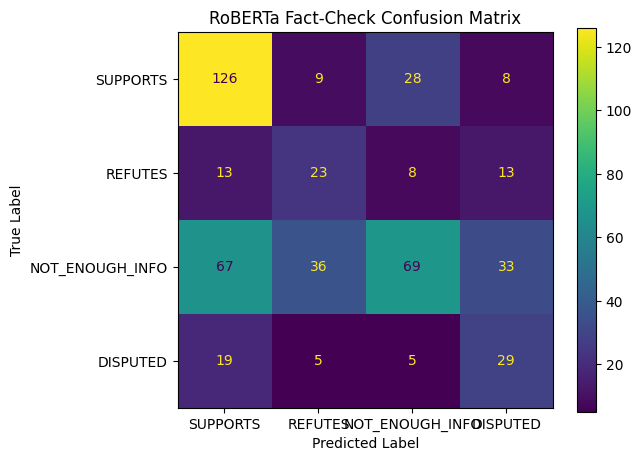

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["SUPPORTS", "REFUTES", "NOT_ENOUGH_INFO", "DISPUTED"]
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format='d')
plt.title("RoBERTa Fact-Check Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Prioritise precision if wanting to avoid spreading false info

Prio recall if wanting to cautch as many wrong claims as possible...

We want to prio precision, especially for refutes and disputed, we would rather miss some false claims than wrongly call something false.

prio F1 for supports, and recall for not_enough_info



In [ ]:
#TO-DO

# Add class weights / over sample Refutes/Disputed examples
# LOOK AT WHAT KIND OF DISPUTED CLAIMS ARE MISSED

# use better retrieval, (maybe disputed claims get irrelevant evidence from BM25)
# evaluate retrieval quality per class


## model improvements:
# try distilroberta-base or deberta-v3-small
# ensembling or confidence-based reranking

### distilroberta

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.5 MB/s eta 0:00:00


In [ ]:
import evaluate

model_name = "distilroberta-base"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")
    return {"macro_f1": f1["f1"]}

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
import numpy as np

training_args = TrainingArguments(
    output_dir="./distilroberta_factcheck",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    learning_rate=2e-5,
    weight_decay=0.05,  # regularization
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_dev,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
<ipython-input-110-065a2fcb2460>:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Macro F1
1,1.071300,1.131367,0.331488
2,0.633600,1.513780,0.401919
3,0.333500,2.267989,0.381867
4,0.164500,2.375029,0.447986
5,0.091800,3.099828,0.420641
6,0.042500,3.258609,0.420118


TrainOutput(global_step=1548, training_loss=0.38951726046027446, metrics={'train_runtime': 605.2453, 'train_samples_per_second': 68.105, 'train_steps_per_second': 4.263, 'total_flos': 1638150277865472.0, 'train_loss': 0.38951726046027446, 'epoch': 6.0})

In [ ]:
# GOLDEN EVIDENCE (oracle)

predictions_dev = trainer.predict(ds_dev)
y_true = predictions_dev.label_ids
y_pred = predictions_dev.predictions.argmax(-1)

In [ ]:
#
print(classification_report(y_true, y_pred, target_names=["SUPPORTS", "REFUTES", "NOT_ENOUGH_INFO", "DISPUTED"]))

                 precision    recall  f1-score   support

       SUPPORTS       0.59      0.74      0.66       171
        REFUTES       0.32      0.33      0.33        57
NOT_ENOUGH_INFO       0.59      0.40      0.47       205
       DISPUTED       0.28      0.40      0.33        58

       accuracy                           0.51       491
      macro avg       0.45      0.47      0.45       491
   weighted avg       0.52      0.51      0.50       491



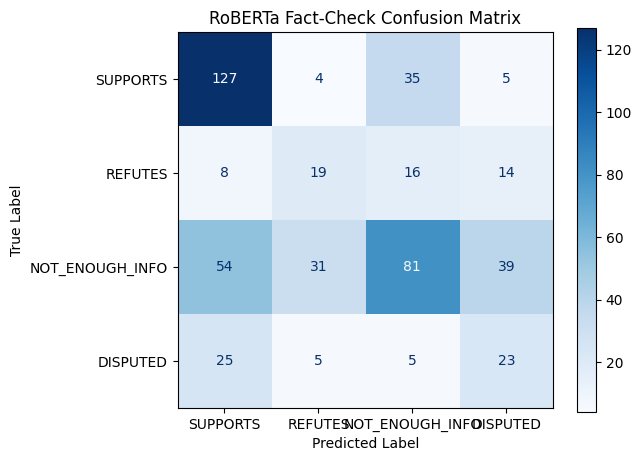

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["SUPPORTS", "REFUTES", "NOT_ENOUGH_INFO", "DISPUTED"]
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("RoBERTa Fact-Check Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

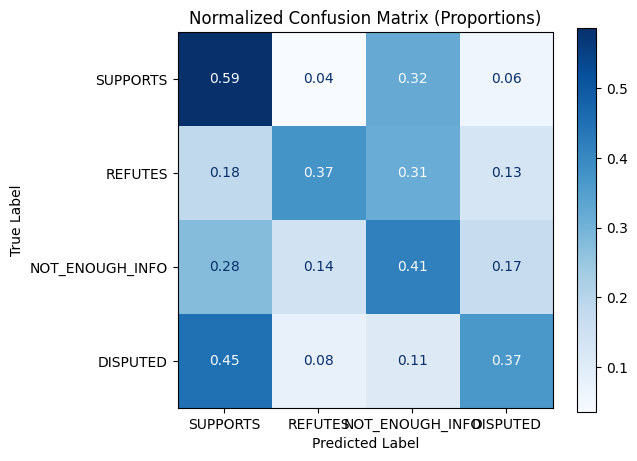

In [ ]:

labels = ["SUPPORTS", "REFUTES", "NOT_ENOUGH_INFO", "DISPUTED"]

cm_raw = confusion_matrix(y_true, y_pred)

cm_norm = cm_raw.astype('float') / cm_raw.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format=".2f")  # shows floats like 0.75
plt.title("Normalized Confusion Matrix (Proportions)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

macro F1: 0.49 -> significantly better (was 0.37 in original run)

DISPUTED and REFUTES are no longer completely failing

SUPPORTS recall remains high

model is less biased toward overpredicting SUPPORTS or NEI

In [ ]:
# pass the Hugging Face Dataset to the trainer.predict method
predictions_dev_hybrid = trainer.predict(ds_dev_hybrid)

# predictions object
y_true = predictions_dev_hybrid.label_ids
y_pred = predictions_dev_hybrid.predictions.argmax(-1)

In [ ]:
print(classification_report(y_true, y_pred, target_names=["SUPPORTS", "REFUTES", "NOT_ENOUGH_INFO", "DISPUTED"]))

                 precision    recall  f1-score   support

       SUPPORTS       0.62      0.59      0.60       680
        REFUTES       0.51      0.37      0.43       270
NOT_ENOUGH_INFO       0.35      0.41      0.38       410
       DISPUTED       0.31      0.37      0.34       180

       accuracy                           0.48      1540
      macro avg       0.45      0.44      0.44      1540
   weighted avg       0.49      0.48      0.48      1540



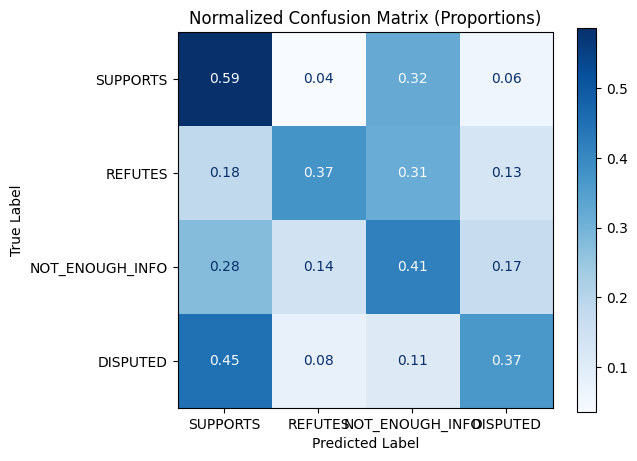

In [ ]:
labels = ["SUPPORTS", "REFUTES", "NOT_ENOUGH_INFO", "DISPUTED"]

cm_raw = confusion_matrix(y_true, y_pred)

cm_norm = cm_raw.astype('float') / cm_raw.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format=".2f")  # shows floats like 0.75
plt.title("Normalized Confusion Matrix (Proportions)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Compared to earlier “oracle” setup where the model was fed the gold evidence—this new result with FAISS‐retrieved evidence is worse overall (as expected)

Macro-F1 dropped from ~0.49 to 0.43

Weighted F1 also dipped from ~0.53 to ~0.48

The biggest hits are on the harder classes (NOT_ENOUGH_INFO and DISPUTED), which probably rely heavily on seeing the right snippets.

this probably means:
Retrieval errors propagate—mis-ranked or missing passages hurt the verifier.
There’s room to improve the retrieval stage (or make the verifier more robust to noisy evidence).

##Mixed Evidence Graph:



### golden evidence

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, f1_score

In [ ]:
def build_grouped_df(df, k=5):
    grouped = []
    for cid, grp in df.groupby('claim_id'):
        claim_text = grp['claim'].iloc[0]
        evs = grp['evidence'].tolist()
        # pad or truncate to k evidences
        if len(evs) < k:
            evs += [""] * (k - len(evs))
        else:
            evs = evs[:k]
        label = grp['label'].iloc[0]
        grouped.append({'claim': claim_text, 'evidences': evs, 'label': label})
    return pd.DataFrame(grouped)

k = 5
train_samples = build_grouped_df(train_df, k)
dev_samples = build_grouped_df(dev_df, k)

In [ ]:
#define dataset and collator classes, and the model, look at bottom section for OOP


In [ ]:
# Prepare DataLoaders, model, optimizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained('distilroberta-base')
model = EvidenceFusionVerifier(num_evidence=k).to(device)

train_ds = FactCheckDataset(train_samples)
dev_ds   = FactCheckDataset(dev_samples)

collator = Collator(tokenizer, k=k)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collator)
dev_loader   = DataLoader(dev_ds,   batch_size=16, shuffle=False, collate_fn=collator)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=2e-5, weight_decay=0.05
)
criterion = nn.CrossEntropyLoss()

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
# Training loop with early stopping
best_f1 = 0.0
patience, trials = 2, 0
for epoch in range(1, 11):
    # Train
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        logits = model(**inputs)
        loss = criterion(logits, batch['labels'].to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch} train loss: {total_loss/len(train_loader):.4f}")

    # Validate
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dev_loader:
            inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            logits = model(**inputs)
            preds = logits.argmax(dim=-1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].tolist())
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"Epoch {epoch} dev macro-F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        trials = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        trials += 1
        if trials >= patience:
            print("Early stopping triggered")
            break

Epoch 1 train loss: 1.0466
Epoch 1 dev macro-F1: 0.4506
Epoch 2 train loss: 0.7583
Epoch 2 dev macro-F1: 0.5055
Epoch 3 train loss: 0.5992
Epoch 3 dev macro-F1: 0.5546
Epoch 4 train loss: 0.4158
Epoch 4 dev macro-F1: 0.5768
Epoch 5 train loss: 0.2389
Epoch 5 dev macro-F1: 0.6569
Epoch 6 train loss: 0.1727
Epoch 6 dev macro-F1: 0.5910
Epoch 7 train loss: 0.0742
Epoch 7 dev macro-F1: 0.6367
Early stopping triggered


In [ ]:
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
print("Final Evaluation on Dev Set:")
print(classification_report(all_labels, all_preds,
      target_names=["SUPPORTS","REFUTES","NOT_ENOUGH_INFO","DISPUTED"]))

Final Evaluation on Dev Set:
                 precision    recall  f1-score   support

       SUPPORTS       0.63      0.43      0.51        68
        REFUTES       0.75      0.11      0.19        27
NOT_ENOUGH_INFO       0.28      0.66      0.39        41
       DISPUTED       0.17      0.06      0.08        18

       accuracy                           0.39       154
      macro avg       0.46      0.31      0.29       154
   weighted avg       0.50      0.39      0.37       154



### predicted evidence

In [ ]:
model2 = EvidenceFusionVerifier(num_evidence=k).to(device)

k = 5
train_samples = build_grouped_df(train_df, k)
dev_samples = build_grouped_df(dev_hybrid, k)

train_ds2 = FactCheckDataset(train_samples)
dev_ds2 = FactCheckDataset(dev_samples)

collator = Collator(tokenizer, k=k)
train_loader = DataLoader(train_ds2, batch_size=16, shuffle=True, collate_fn=collator)
dev_loader   = DataLoader(dev_ds2,   batch_size=16, shuffle=False, collate_fn=collator)

optimizer = torch.optim.AdamW(
    model2.parameters(), lr=2e-5, weight_decay=0.05
)
criterion = nn.CrossEntropyLoss()

In [ ]:
# Training loop with early stopping
best_f1 = 0.0
patience, trials = 2, 0
for epoch in range(1, 11):
    # Train
    model2.train()
    total_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        logits = model2(**inputs)
        loss = criterion(logits, batch['labels'].to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch} train loss: {total_loss/len(train_loader):.4f}")

    # Validate
    model2.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dev_loader:
            inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            logits = model2(**inputs)
            preds = logits.argmax(dim=-1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].tolist())
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"Epoch {epoch} dev macro-F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        trials = 0
        torch.save(model2.state_dict(), 'best_model.pt')
    else:
        trials += 1
        if trials >= patience:
            print("Early stopping triggered")
            break

Epoch 1 train loss: 1.2619
Epoch 1 dev macro-F1: 0.2770
Epoch 2 train loss: 1.0948
Epoch 2 dev macro-F1: 0.3552
Epoch 3 train loss: 0.8658
Epoch 3 dev macro-F1: 0.3851
Epoch 4 train loss: 0.5477
Epoch 4 dev macro-F1: 0.4444
Epoch 5 train loss: 0.3409
Epoch 5 dev macro-F1: 0.4234
Epoch 6 train loss: 0.1977
Epoch 6 dev macro-F1: 0.4372
Early stopping triggered


In [ ]:
model2.load_state_dict(torch.load('best_model.pt'))
model2.eval()
print("Final Evaluation on Predicted Dev Set:")
print(classification_report(all_labels, all_preds,
      target_names=["SUPPORTS","REFUTES","NOT_ENOUGH_INFO","DISPUTED"]))

Final Evaluation on Predicated Dev Set:
                 precision    recall  f1-score   support

       SUPPORTS       0.63      0.62      0.62        68
        REFUTES       0.57      0.15      0.24        27
NOT_ENOUGH_INFO       0.40      0.51      0.45        41
       DISPUTED       0.37      0.56      0.44        18

       accuracy                           0.50       154
      macro avg       0.49      0.46      0.44       154
   weighted avg       0.53      0.50      0.49       154



We output our predictions as a json file

In [ ]:
all_label = [labels[i] for i in all_preds]
original_order = dev_hybrid['claim_id'].unique()
grouped_df = (
    dev_hybrid
    .groupby('claim_id', sort=False)
    .agg({
        'evidence_id': list,
        'claim': 'first',
        'label': 'first'
    })
    .reindex(original_order)
    .reset_index()
)
grouped_df['claim_label'] = all_label
grouped_df = grouped_df.drop(columns=['label'])
grouped_df = grouped_df.rename(columns={'claim': 'claim_text'})
grouped_df = grouped_df.rename(columns={'evidence_id': 'evidences'})

claims_dict = grouped_df.set_index('claim_id').to_dict(orient='index')
print(claims_dict)
#save as json file
with open("/content/drive/MyDrive/Colab Notebooks/comp90042_a3/data/predictions.json", "w") as json_file:
    json.dump(claims_dict, json_file, indent=2)

{'claim-752': {'evidences': ['evidence-416100', 'evidence-23321', 'evidence-1045931', 'evidence-1208472', 'evidence-150869', 'evidence-984053', 'evidence-119916', 'evidence-1140258', 'evidence-1194199', 'evidence-666596'], 'claim_text': '[South Australia] has the most expensive electricity in the world.', 'claim_label': 'DISPUTED'}, 'claim-375': {'evidences': ['evidence-531774', 'evidence-97351', 'evidence-931737', 'evidence-430393', 'evidence-788947', 'evidence-1190705', 'evidence-998171', 'evidence-904753', 'evidence-488727', 'evidence-1117137'], 'claim_text': 'when 3 per cent of total annual global emissions of carbon dioxide are from humans and Australia prod\xaduces 1.3 per cent of this 3 per cent, then no amount of emissions reductio\xadn here will have any effect on global climate.', 'claim_label': 'SUPPORTS'}, 'claim-1266': {'evidences': ['evidence-889933', 'evidence-91685', 'evidence-232879', 'evidence-682177', 'evidence-219259', 'evidence-533805', 'evidence-423243', 'evidence

# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
!python /content/drive/MyDrive/Colab\ Notebooks/comp90042_a3/data/eval.py \
    --predictions "/content/drive/MyDrive/Colab Notebooks/comp90042_a3/data/predictions.json" \
    --groundtruth "/content/drive/MyDrive/Colab Notebooks/comp90042_a3/data/dev-claims.json"


Evidence Retrieval F-score (F)    = 0.055004735524216045
Claim Classification Accuracy (A) = 0.33116883116883117
Harmonic Mean of F and A          = 0.09434024254065175


In [ ]:
!pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt

## Retrival Evaluation

### Recall@k

In [ ]:
def recall_at_k(true_dict, pred_dict, k):

    recalls = []
    for cid, gold in true_dict.items():
        retrieved = pred_dict.get(cid, [])[:k]
        if gold:
            recalls.append(len(set(gold) & set(retrieved)) / len(gold))
    return sum(recalls) / len(recalls)

### Precision@k

In [ ]:
def precision_at_k(true_dict, pred_dict, k):
    precisions = []
    for cid, pred in pred_dict.items():
        pred_topk = pred[:k]
        gold = true_dict.get(cid, [])
        precisions.append(len(set(gold) & set(pred_topk)) / k)
    return sum(precisions) / len(precisions)

In [ ]:
methods = {
    "BM25":   bm25_pred_dict,
    "FAISS":  faiss_pred_dict
}

In [ ]:
def plot_retrieval_ablation(true_evidence_dict, methods_dict, ks):

    plt.figure()
    for method_name, pred_dict in methods_dict.items():
        recalls = [recall_at_k(true_evidence_dict, pred_dict, k) for k in ks]
        plt.plot(ks, recalls, marker='o', label=method_name)

    plt.xlabel('k (top-k retrieved)')
    plt.ylabel('Recall@k')
    plt.title('Retrieval Ablation Curves')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig('retrieval_ablation_curves.png')

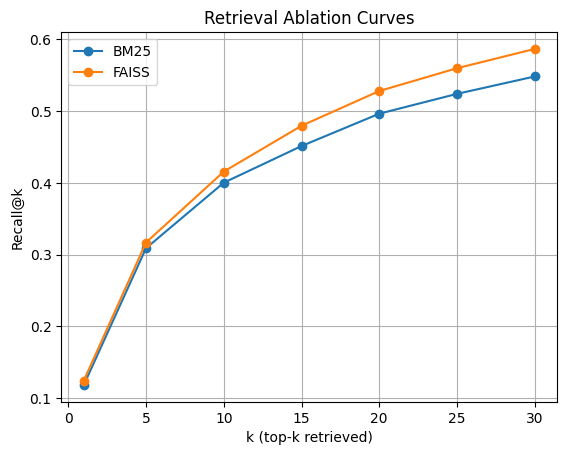

<Figure size 640x480 with 0 Axes>

In [ ]:
ks = [1, 5, 10, 15, 20, 25, 30]
plot_retrieval_ablation(true_evidence_dict, methods, ks)

## Classifiation Evaluation

## Object Oriented Programming codes here

*You can use multiple code snippets. Just add more if needed*

In [ ]:
#Dataset and Collator classes

class FactCheckDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        row = self.samples.loc[idx]
        return row['claim'], row['evidences'], row['label']

class Collator:
    def __init__(self, tokenizer, k=5, max_length=256):
        self.tokenizer = tokenizer
        self.k = k
        self.max_length = max_length
    def __call__(self, batch):
        claims, all_evs, labels = zip(*batch)
        flat_evs = [ev for evs in all_evs for ev in evs]
        enc_claim = self.tokenizer(
            list(claims), padding=True, truncation=True,
            max_length=self.max_length, return_tensors='pt'
        )
        enc_evs = self.tokenizer(
            flat_evs, padding=True, truncation=True,
            max_length=self.max_length, return_tensors='pt'
        )
        # reshape evidences to (B, k, seq_len)
        B = len(batch)
        input_ids_evs = enc_evs['input_ids'].view(B, self.k, -1)
        mask_evs      = enc_evs['attention_mask'].view(B, self.k, -1)
        return {
            'claim_input_ids': enc_claim['input_ids'],
            'claim_attention_mask': enc_claim['attention_mask'],
            'evidence_input_ids': input_ids_evs,
            'evidence_attention_mask': mask_evs,
            'labels': torch.tensor(labels)
        }

In [ ]:
# Define the EvidenceFusionVerifier model
class EvidenceFusionVerifier(nn.Module):
    def __init__(self,
                 base_model_name='distilroberta-base',
                 num_evidence=5,
                 transformer_layers=2,
                 hidden_size=768,
                 batch_first=True,
                 num_labels=4):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model_name)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=8,
            batch_first=batch_first,
            activation='gelu',
            dim_feedforward=hidden_size * 4
        )
        self.fusion = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers, enable_nested_tensor=True)
        self.classifier = nn.Linear(hidden_size, num_labels)
        self.k = num_evidence

    def forward(self,
                claim_input_ids, claim_attention_mask,
                evidence_input_ids, evidence_attention_mask):
        B = claim_input_ids.size(0)
        # Encode claim
        claim_out = self.encoder(
            input_ids=claim_input_ids,
            attention_mask=claim_attention_mask
        )
        claim_emb = claim_out.last_hidden_state[:, 0]
        # Encode evidences (flatten batch*k)
        flat_ids = evidence_input_ids.view(B * self.k, -1)
        flat_mask = evidence_attention_mask.view(B * self.k, -1)
        ev_out = self.encoder(input_ids=flat_ids, attention_mask=flat_mask)
        ev_emb = ev_out.last_hidden_state[:, 0].view(B, self.k, -1)
        # Fuse claim + evidences
        seq = torch.cat([claim_emb.unsqueeze(1), ev_emb], dim=1).transpose(0,1)
        fused = self.fusion(seq)
        pooled = fused[0]
        logits = self.classifier(pooled)
        return logits